# Neural Competing Risk Model

## Objective
This notebook trains a 3-class neural competing-risk model to predict the next loan outcome:

- continue
- default
- prepay

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import json
import time
import random
from dataclasses import dataclass, asdict
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, log_loss
import joblib

In [4]:
PROJECT_DIR = "/content/drive/MyDrive/loan_project_ncr"
DATA_PATH = os.path.join(PROJECT_DIR, "monthly_df_tb3ms_borrower_seasoning.parquet")

monthly_df = pd.read_parquet(DATA_PATH)
print("Loaded monthly_df:", monthly_df.shape)
monthly_df.head()

Loaded monthly_df: (1656440, 38)


,loan_id,cohort_year,month_since_orig,status_next,tbill_level,tbill_change_3m,apr_tbill_spread,apr_tbill_spread_change_3m,apr_tbill_spread_pct,borrower_apr,...,open_credit_lines_is_missing,revolving_balance_is_missing,bankcard_util_is_missing,available_bankcard_credit_is_missing,income_range_is_missing,employment_status_is_missing,homeowner_is_missing,spread_x_seasoning,rate_change_x_seasoning,spread_pct_x_seasoning
0,0,2007,1,0.0,0.0420,-0.0053,0.1160,-0.0053,0.734177,0.158,...,0,0,0,0,0,0,0,0.1160,-0.0053,0.734177
1,0,2007,2,0.0,0.0389,-0.0072,0.1191,-0.0072,0.753797,0.158,...,0,0,0,0,0,0,0,0.2382,-0.0144,1.507595
2,0,2007,3,0.0,0.0390,-0.0092,0.1190,-0.0092,0.753165,0.158,...,0,0,0,0,0,0,0,0.3570,-0.0276,2.259494
3,0,2007,4,0.0,0.0327,-0.0093,0.1253,-0.0093,0.793038,0.158,...,0,0,0,0,0,0,0,0.5012,-0.0372,3.172152
4,0,2007,5,0.0,0.0300,-0.0089,0.1280,-0.0089,0.810127,0.158,...,0,0,0,0,0,0,0,0.6400,-0.0445,4.050633


## Temporal Split
We use a leakage-safe temporal split based on origination cohort:

- Train: `cohort_year <= 2011`
- Validation: `cohort_year == 2012`
- Test: `cohort_year in {2013, 2014}`

The test set is defined but not used for model development.

In [5]:
features = [
    "month_since_orig",
    "tbill_level",
    "tbill_change_3m",
    "apr_tbill_spread",
    "apr_tbill_spread_change_3m",
    "apr_tbill_spread_pct",
    "spread_x_seasoning",
    "rate_change_x_seasoning",
    "spread_pct_x_seasoning",
    "borrower_apr",
    "loan_amount_log",
    "prosper_score",
    "credit_score_lower",
    "credit_score_upper",
    "dti",
    "delinq_7y",
    "open_credit_lines",
    "revolving_balance",
    "bankcard_util",
    "available_bankcard_credit",
    "income_range",
    "employment_status",
    "homeowner",
    "prosper_score_is_missing",
    "credit_score_lower_is_missing",
    "credit_score_upper_is_missing",
    "dti_is_missing",
    "delinq_7y_is_missing",
    "open_credit_lines_is_missing",
    "revolving_balance_is_missing",
    "bankcard_util_is_missing",
    "available_bankcard_credit_is_missing",
    "income_range_is_missing",
    "employment_status_is_missing",
    "homeowner_is_missing",
]

In [6]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


@dataclass
class TrainConfig:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    out_dir: str = os.path.join(PROJECT_DIR, "ncr_runs", "run_tb3ms_seasoning_clean")
    batch_size: int = 4096
    max_epochs: int = 30
    patience: int = 5
    min_delta: float = 1e-4
    grad_clip_norm: float = 5.0
    num_workers: int = 0
    train_year_max: int = 2011
    val_years: Tuple[int, ...] = (2012,)
    test_years: Tuple[int, ...] = (2013, 2014)
    hidden_sizes: Tuple[int, ...] = (256, 128)
    dropout: float = 0.15
    lr: float = 3e-4
    weight_decay: float = 1e-3
    use_class_weights: bool = True

In [7]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class NCRMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes=(256, 128), dropout=0.15):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev, 3)

    def forward(self, x):
        z = self.backbone(x)
        return self.head(z)

In [8]:
def prepare_splits(monthly_df: pd.DataFrame, cfg: TrainConfig):
    train_df = monthly_df[monthly_df["cohort_year"] <= cfg.train_year_max].copy()
    val_df = monthly_df[monthly_df["cohort_year"].isin(cfg.val_years)].copy()
    test_df = monthly_df[monthly_df["cohort_year"].isin(cfg.test_years)].copy()
    print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})
    return train_df, val_df, test_df


def map_labels_to_order(y_raw: np.ndarray) -> np.ndarray:
    # raw: 0=continue, 1=prepay, 2=default
    # mapped: 0=continue, 1=default, 2=prepay
    y = np.empty_like(y_raw.astype(np.int64))
    y[y_raw == 0] = 0
    y[y_raw == 2] = 1
    y[y_raw == 1] = 2
    return y


def compute_class_weights(y_train: np.ndarray) -> torch.Tensor:
    counts = np.bincount(y_train, minlength=3).astype(np.float64)
    n = counts.sum()
    w = n / (3.0 * np.maximum(counts, 1.0))
    return torch.tensor(w, dtype=torch.float32)


@torch.no_grad()
def predict_proba(model, loader, device: str):
    model.eval()
    probs = []
    for xb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)
        probs.append(p.detach().cpu().numpy())
    return np.concatenate(probs, axis=0)


def compute_metrics_3class(y_true: np.ndarray, proba: np.ndarray):
    pr_default = average_precision_score((y_true == 1).astype(int), proba[:, 1])
    pr_prepay = average_precision_score((y_true == 2).astype(int), proba[:, 2])
    ll = log_loss(y_true, proba, labels=[0, 1, 2])
    return {
        "log_loss": float(ll),
        "pr_auc_default": float(pr_default),
        "pr_auc_prepay": float(pr_prepay),
    }

## Preprocessing
Imputation and scaling are fit on the training set only to avoid leakage.

In [9]:
def train_ncr_3class(monthly_df: pd.DataFrame, features: List[str], cfg: TrainConfig):
    seed_everything(cfg.seed)
    os.makedirs(cfg.out_dir, exist_ok=True)

    meta = {
        **asdict(cfg),
        "features": features,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "torch_version": torch.__version__,
    }
    with open(os.path.join(cfg.out_dir, "config.json"), "w") as f:
        json.dump(meta, f, indent=2)

    train_df, val_df, test_df = prepare_splits(monthly_df, cfg)

    X_train_raw = train_df[features].to_numpy(dtype=np.float32)
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train_raw)

    scaler = StandardScaler()
    scaler.fit(X_train_imp)

    joblib.dump(imputer, os.path.join(cfg.out_dir, "imputer.joblib"))
    np.save(os.path.join(cfg.out_dir, "scaler_mean.npy"), scaler.mean_)
    np.save(os.path.join(cfg.out_dir, "scaler_scale.npy"), scaler.scale_)

    def transform(df_):
        X = df_[features].to_numpy(dtype=np.float32)
        X = imputer.transform(X)
        X = scaler.transform(X)
        y_raw = df_["status_next"].to_numpy(dtype=np.int64)
        y = map_labels_to_order(y_raw)
        return X, y

    X_train, y_train = transform(train_df)
    X_val, y_val = transform(val_df)

    train_loader = DataLoader(
        TabularDataset(X_train, y_train),
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )
    val_loader = DataLoader(
        TabularDataset(X_val, y_val),
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )

    model = NCRMLP(
        input_dim=len(features),
        hidden_sizes=cfg.hidden_sizes,
        dropout=cfg.dropout
    ).to(cfg.device)

    if cfg.use_class_weights:
        w = compute_class_weights(y_train).to(cfg.device)
        criterion = nn.CrossEntropyLoss(weight=w)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    use_amp = (cfg.device == "cuda")
    scaler_amp = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val = float("inf")
    best_epoch = -1
    bad_epochs = 0
    history = {"train": [], "val": []}
    best_path = os.path.join(cfg.out_dir, "best.pt")

    for epoch in range(1, cfg.max_epochs + 1):
        t0 = time.time()

        model.train()
        total = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(cfg.device, non_blocking=True)
            yb = yb.to(cfg.device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
            scaler_amp.step(optimizer)
            scaler_amp.update()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total / max(n, 1)

        model.eval()
        vtotal = 0.0
        vn = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(cfg.device, non_blocking=True)
                yb = yb.to(cfg.device, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = model(xb)
                    loss = criterion(logits, yb)

                vtotal += loss.item() * xb.size(0)
                vn += xb.size(0)

        val_loss = vtotal / max(vn, 1)
        scheduler.step(val_loss)

        val_proba = predict_proba(model, val_loader, cfg.device)
        val_metrics = compute_metrics_3class(y_val, val_proba)

        history["train"].append({"epoch": epoch, "loss": float(train_loss)})
        history["val"].append({"epoch": epoch, "loss": float(val_loss), **val_metrics})

        improved = (best_val - val_loss) > cfg.min_delta
        if improved:
            best_val = val_loss
            best_epoch = epoch
            bad_epochs = 0
            torch.save(model.state_dict(), best_path)
        else:
            bad_epochs += 1

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.5f} val_loss={val_loss:.5f} | "
            f"default={val_metrics['pr_auc_default']:.4f} "
            f"prepay={val_metrics['pr_auc_prepay']:.4f} | "
            f"time={time.time()-t0:.1f}s"
        )

        if bad_epochs >= cfg.patience:
            print(f"Early stopping at epoch {epoch}. Best epoch={best_epoch}")
            break

    with open(os.path.join(cfg.out_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, map_location=cfg.device))

    best_val_summary = history["val"][best_epoch - 1] if best_epoch > 0 else history["val"][-1]
    return history, best_val_summary

In [11]:
cfg = TrainConfig()
history, best_val = train_ncr_3class(monthly_df, features, cfg)
best_val

{'train': 702485, 'val': 283842, 'test': 670113}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train_loss=1.00727 val_loss=1.02023 | default=0.0101 prepay=0.0133 | time=43.3s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | train_loss=0.96029 val_loss=0.99704 | default=0.0133 prepay=0.0141 | time=31.7s


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 21 | train_loss=0.90376 val_loss=0.96031 | default=0.0176 prepay=0.0151 | time=29.4s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 22 | train_loss=0.90498 val_loss=0.96203 | default=0.0178 prepay=0.0148 | time=29.1s
Early stopping at epoch 22. Best epoch=17


{'epoch': 17,
 'loss': 0.9569674406085336,
 'log_loss': 0.964252063263735,
 'pr_auc_default': 0.017719355517420026,
 'pr_auc_prepay': 0.015126563493230372}

## Interpretation
The NCR model provides a strong neural baseline for this problem.

It is especially competitive for default prediction, while prepayment prediction remains somewhat weaker than the strongest tree-based tabular baseline.

## Validation Summary

The table below summarizes the best validation performance of the NCR model on the 2012 cohort.

This notebook focuses on the neural competing-risk model only. Final model selection is handled in the model comparison notebook.

The NCR model achieves:

- Default PR-AUC ≈ 0.0177
- Prepay PR-AUC ≈ 0.0151

This indicates that the model captures meaningful signal, especially for default prediction.

In [12]:
import pandas as pd

ncr_results = pd.DataFrame([{
    "model": "NCR_3class",
    "best_epoch": best_val["epoch"],
    "log_loss": best_val["log_loss"],
    "pr_auc_default": best_val["pr_auc_default"],
    "pr_auc_prepay": best_val["pr_auc_prepay"],
}])

ncr_results

,model,best_epoch,log_loss,pr_auc_default,pr_auc_prepay
0,NCR_3class,17,0.964252,0.017719,0.015127


## Training Diagnostics

To understand model behavior, we inspect:
- training vs validation loss
- validation PR-AUC across epochs

These diagnostics help us check whether training is stable and whether early stopping is reasonable.

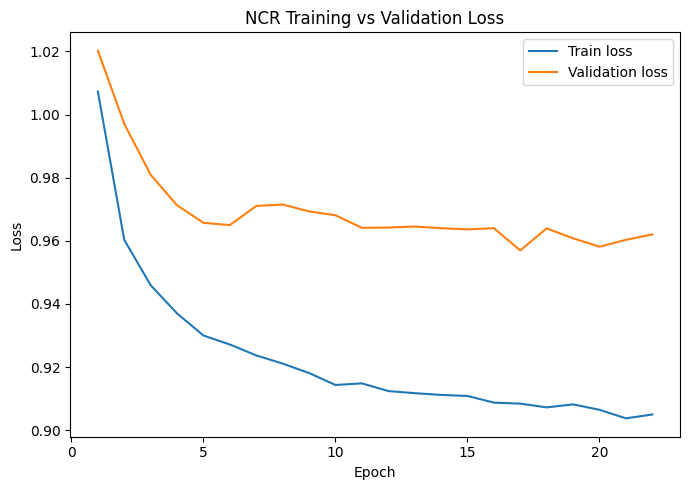

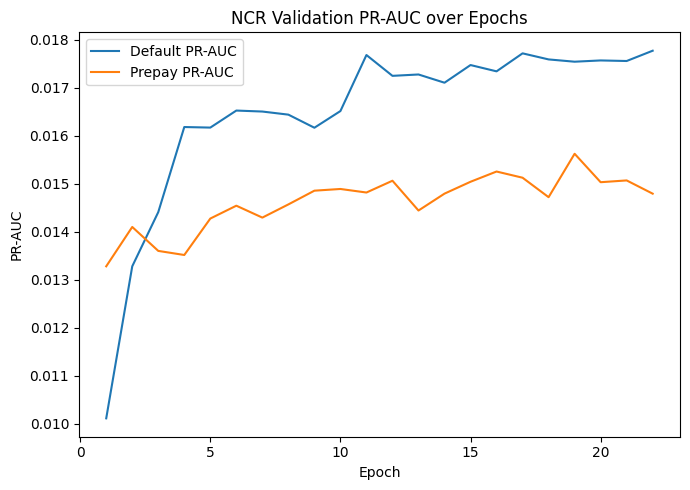

Saved: /content/drive/MyDrive/loan_project_ncr/figures/ncr_loss_curve.png
Saved: /content/drive/MyDrive/loan_project_ncr/figures/ncr_prauc_over_epochs.png


In [13]:
import os
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

train_hist = pd.DataFrame(history["train"])
val_hist = pd.DataFrame(history["val"])

# Plot 1: Training vs validation loss
plt.figure(figsize=(7, 5))
plt.plot(train_hist["epoch"], train_hist["loss"], label="Train loss")
plt.plot(val_hist["epoch"], val_hist["loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NCR Training vs Validation Loss")
plt.legend()
plt.tight_layout()
ncr_loss_path = os.path.join(FIG_DIR, "ncr_loss_curve.png")
plt.savefig(ncr_loss_path, dpi=200, bbox_inches="tight")
plt.show()

# Plot 2: Validation PR-AUC over epochs
plt.figure(figsize=(7, 5))
plt.plot(val_hist["epoch"], val_hist["pr_auc_default"], label="Default PR-AUC")
plt.plot(val_hist["epoch"], val_hist["pr_auc_prepay"], label="Prepay PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("NCR Validation PR-AUC over Epochs")
plt.legend()
plt.tight_layout()
ncr_prauc_path = os.path.join(FIG_DIR, "ncr_prauc_over_epochs.png")
plt.savefig(ncr_prauc_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ncr_loss_path)
print("Saved:", ncr_prauc_path)

## Ranking Performance

PR-AUC summarizes rare-event ranking quality overall, but it does not directly show how many real events are concentrated in the highest-risk segment.

To complement PR-AUC, we report lift-style capture metrics:
- top 5% capture
- top 10% capture

This provides a more operational view of model usefulness.

In [14]:
import numpy as np
import pandas as pd

def compute_lift(y_true, proba, event_class, top_frac=0.1):
    """
    y_true: integer labels (0=continue,1=default,2=prepay)
    proba: predicted probabilities (n_samples x 3)
    event_class: 1 for default, 2 for prepay
    top_frac: fraction of population (0.05 or 0.10)
    """

    event = (y_true == event_class).astype(int)
    score = proba[:, event_class]

    df = pd.DataFrame({
        "event": event,
        "score": score
    })

    df = df.sort_values("score", ascending=False)

    k = int(len(df) * top_frac)

    top = df.iloc[:k]

    captured = top["event"].sum()
    total = df["event"].sum()

    capture_rate = captured / total

    return {
        "top_frac": top_frac,
        "captured_events": int(captured),
        "total_events": int(total),
        "capture_rate": capture_rate
    }

In [15]:
def predict_proba(model, loader, device: str) -> np.ndarray:
    model.eval()
    probs = []
    for xb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)
        probs.append(p.detach().cpu().numpy())
    return np.concatenate(probs, axis=0)

def compute_metrics_3class(y_true: np.ndarray, proba: np.ndarray) -> dict:
    """
    y_true labels: 0=continue, 1=default, 2=prepay
    proba columns correspond to same order.
    """
    # PR-AUC one-vs-rest
    pr_default = average_precision_score((y_true == 1).astype(int), proba[:, 1])
    pr_prepay  = average_precision_score((y_true == 2).astype(int), proba[:, 2])
    ll = log_loss(y_true, proba, labels=[0, 1, 2])
    return {"log_loss": float(ll), "pr_auc_default": float(pr_default), "pr_auc_prepay": float(pr_prepay)}


In [17]:
lift_default_5_ncr = compute_lift(y_val, ncr_val_proba, 1, 0.05)
lift_default_10_ncr = compute_lift(y_val, ncr_val_proba, 1, 0.10)

lift_prepay_5_ncr = compute_lift(y_val, ncr_val_proba, 2, 0.05)
lift_prepay_10_ncr = compute_lift(y_val, ncr_val_proba, 2, 0.10)

print("NCR lift (validation):")
print("Default top 5%:", lift_default_5_ncr)
print("Default top 10%:", lift_default_10_ncr)

print("Prepay top 5%:", lift_prepay_5_ncr)
print("Prepay top 10%:", lift_prepay_10_ncr)

NCR lift (validation):
Default top 5%: {'top_frac': 0.05, 'captured_events': 300, 'total_events': 1326, 'capture_rate': np.float64(0.22624434389140272)}
Default top 10%: {'top_frac': 0.1, 'captured_events': 534, 'total_events': 1326, 'capture_rate': np.float64(0.40271493212669685)}
Prepay top 5%: {'top_frac': 0.05, 'captured_events': 279, 'total_events': 2836, 'capture_rate': np.float64(0.09837799717912553)}
Prepay top 10%: {'top_frac': 0.1, 'captured_events': 469, 'total_events': 2836, 'capture_rate': np.float64(0.1653737658674189)}


The table below summarizes NCR top-segment capture on the validation cohort.

In [18]:
ncr_lift_summary = pd.DataFrame([
    {"model": "NCR", "event": "Default", "top_5_capture": lift_default_5_ncr["capture_rate"], "top_10_capture": lift_default_10_ncr["capture_rate"]},
    {"model": "NCR", "event": "Prepay", "top_5_capture": lift_prepay_5_ncr["capture_rate"], "top_10_capture": lift_prepay_10_ncr["capture_rate"]},
])

ncr_lift_summary

,model,event,top_5_capture,top_10_capture
0,NCR,Default,0.226244,0.402715
1,NCR,Prepay,0.098378,0.165374


## Takeaway

The NCR model is a strong neural baseline for this problem.

It performs competitively for default prediction, while prepayment remains harder to model. Final model selection should be based on the cross-model comparison notebook.